Kept 61/76 programs, 77 cell types  (q=0.2)
Trunk channels: 17 (was 61 before reuse)


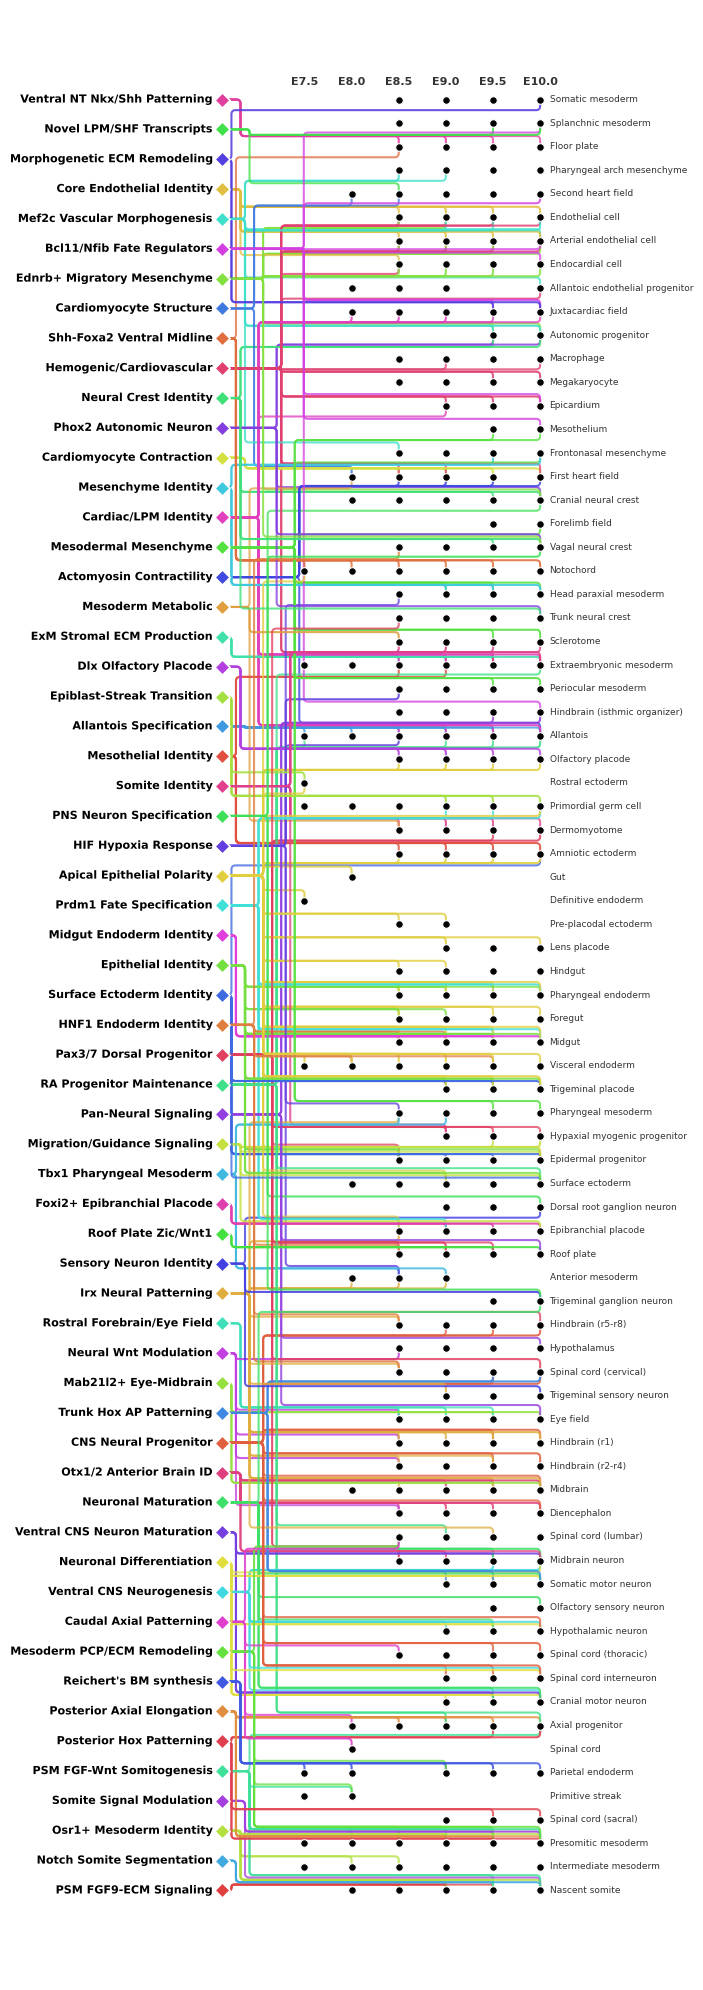

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from collections import defaultdict
import colorsys


# configuration

def prog_colormap(n, saturation=0.72, value=0.88):
    """hsv with golden-ratio stride shuffle for max adjacent contrast."""
    hues = np.linspace(0, 1, n, endpoint=False)
    golden = (1 + 5**0.5) / 2
    order = sorted(range(n), key=lambda i: (i * golden) % 1)
    return [colorsys.hsv_to_rgb(hues[idx], saturation, value) for idx in order]

CT_NODE_COLORS = {}
CT_NODE_DEFAULT = "black"

FILTER_QUANTILE = 0.2        # 0 = keep all
SCORE_THRESHOLD = 0.8        # min normalised score to keep

FIG_SIZE        = (8, 20)
GRID_SPACING_X  = 2.0
GRID_SPACING_Y  = 1.0

# layout and routing params
#
# PROG_COL_OFFSET      gap from leftmost stage column to program nodes
# PROG_NODE_CLEARANCE  horizontal clearance right of program nodes before trunk starts
# TRUNK_MARGIN_INNER   padding between trunk zone right edge and grid
# PARALLEL_OFFSET      vertical shift per extra edge sharing a corridor
# CORRIDOR_MARGIN      pulls corridor baseline toward target row from midpoint
# CORNER_RADIUS        rounding radius at bends

PROG_COL_OFFSET      = 3.5
PROG_NODE_CLEARANCE  = 0.4
TRUNK_MARGIN_INNER   = 0.03
PARALLEL_OFFSET      = 0.1
CORRIDOR_MARGIN      = 0.05
CORNER_RADIUS        = 0.18
CORNER_ARC_PTS       = 10
TRUNK_PAD            = 0.05

EDGE_ALPHA         = (0.20, 0.88)
EDGE_LW            = (1.5, 1.5)
EDGE_WEIGHT_THRESH = 0.0

GRID_NODE_SIZE       = 30
PROG_NODE_SIZE       = 60
PROG_LABEL_FONTSIZE  = 8
STAGE_LABEL_FONTSIZE = 8
CT_LABEL_FONTSIZE    = 6.5
LABEL_OFFSET         = 0.42


score_df = pd.read_csv('programs/program_scores_by_stage.csv', index_col=0)
annotation_df = pd.read_csv('programs/annotated_programs.csv', index_col=0)
prog_name_map = annotation_df['name'].to_dict()

prog_vals = score_df[score_df.columns.difference(['cell_type', 'stage'])]
mins, maxs = prog_vals.min(), prog_vals.max()
score_df[prog_vals.columns] = (prog_vals - mins) / (maxs - mins).replace(0, 1)
score_df[prog_vals.columns] = score_df[prog_vals.columns].where(
    score_df[prog_vals.columns] > SCORE_THRESHOLD, 0.0)


# quantile filtering

meta_cols = ["cell_type", "stage"]
_all_progs = [c for c in score_df.columns if c not in meta_cols]

prog_sums = score_df[_all_progs].sum(axis=0)
program_cols = prog_sums[prog_sums >= prog_sums.quantile(FILTER_QUANTILE)].index.tolist()

ct_sums = score_df.groupby("cell_type")[program_cols].sum().sum(axis=1)
keep_cts = ct_sums[ct_sums >= ct_sums.quantile(FILTER_QUANTILE)].index.tolist()

score_df = score_df[score_df["cell_type"].isin(keep_cts)].copy()
print(f"Kept {len(program_cols)}/{len(_all_progs)} programs, "
      f"{len(keep_cts)} cell types  (q={FILTER_QUANTILE})")


# ordering (spectral + barycentric)

stage_order = sorted(score_df["stage"].unique(),
                     key=lambda s: float(s.replace("E", "")))
cell_types_unsorted = sorted(score_df["cell_type"].unique())
n_rows, n_cols, n_programs = len(cell_types_unsorted), len(stage_order), len(program_cols)

ct_prog = np.zeros((n_rows, n_programs))
for idx, ct in enumerate(cell_types_unsorted):
    ct_prog[idx] = score_df[score_df["cell_type"] == ct][program_cols].max(axis=0).values


def spectral_order(W):
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    S = (W / norms) @ (W / norms).T
    np.clip(S, 0, None, out=S)
    np.fill_diagonal(S, 0)
    L = laplacian(S, normed=False)
    _, vecs = eigh(L)
    return np.argsort(vecs[:, 1])


def barycentric_sort(W, fixed_order):
    positions = np.arange(len(fixed_order), dtype=float)
    bary = np.zeros(W.shape[0])
    for i in range(W.shape[0]):
        w = W[i, fixed_order]
        total = w.sum()
        bary[i] = np.dot(w, positions) / total if total > 0 else positions.mean()
    return np.argsort(bary)


ct_perm = spectral_order(ct_prog)
for _ in range(8):
    prog_perm = barycentric_sort(ct_prog.T, ct_perm)
    ct_perm   = barycentric_sort(ct_prog, prog_perm)

cell_types = [cell_types_unsorted[i] for i in ct_perm]
program_cols_ordered = [program_cols[i] for i in prog_perm]
ct_to_row  = {ct: i for i, ct in enumerate(cell_types)}
stage_to_col = {st: j for j, st in enumerate(stage_order)}


# layout
grid_xs = np.arange(n_cols) * GRID_SPACING_X;  grid_xs -= grid_xs.mean()
grid_ys = np.arange(n_rows) * GRID_SPACING_Y;  grid_ys -= grid_ys.mean()

grid_pos = {}
for _, row in score_df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    grid_pos[(ct, st)] = (grid_xs[stage_to_col[st]], grid_ys[ct_to_row[ct]])

prog_x_base = grid_xs.min() - PROG_COL_OFFSET
prog_ys_arr = np.linspace(grid_ys.min(), grid_ys.max(), n_programs)
prog_pos = {pc: (prog_x_base, prog_ys_arr[i])
            for i, pc in enumerate(program_cols_ordered)}


# channel reuse
# trunk zone starts right of program nodes, ends near grid

trunk_zone_L = prog_x_base + PROG_NODE_CLEARANCE
trunk_zone_R = grid_xs.min() - TRUNK_MARGIN_INNER

prog_y_intervals = {}
prog_com_y = {}
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    target_ys, ws = [py], []
    for _, row in score_df.iterrows():
        if row[pc] > EDGE_WEIGHT_THRESH:
            y = grid_ys[ct_to_row[row["cell_type"]]]
            target_ys.append(y)
            ws.append(row[pc])
    prog_y_intervals[pc] = (min(target_ys) - TRUNK_PAD, max(target_ys) + TRUNK_PAD)
    prog_com_y[pc] = (np.average([t for t in target_ys[1:]], weights=ws)
                      if ws else py)

progs_by_com = sorted(program_cols_ordered, key=lambda p: prog_com_y[p])

channels = []
prog_channel = {}
for pc in progs_by_com:
    iv = prog_y_intervals[pc]
    placed = False
    for ci, ext in enumerate(channels):
        if iv[0] >= ext[1] or iv[1] <= ext[0]:
            channels[ci] = (min(ext[0], iv[0]), max(ext[1], iv[1]))
            prog_channel[pc] = ci
            placed = True
            break
    if not placed:
        prog_channel[pc] = len(channels)
        channels.append(iv)

n_channels = len(channels)
print(f"Trunk channels: {n_channels} (was {n_programs} before reuse)")

channel_xs = (np.array([(trunk_zone_L + trunk_zone_R) / 2.0]) if n_channels == 1
              else np.linspace(trunk_zone_L, trunk_zone_R, n_channels))
prog_trunk_x = {pc: channel_xs[prog_channel[pc]] for pc in program_cols_ordered}


# midpoint-based corridor routing
# horizontal segments sit at midpoints between rows so they never cross a node row

row_midpoint_above = {}
row_midpoint_below = {}
for r in range(n_rows):
    if r + 1 < n_rows:
        row_midpoint_above[r] = (grid_ys[r] + grid_ys[r + 1]) / 2.0
    else:
        row_midpoint_above[r] = grid_ys[r] + GRID_SPACING_Y / 2.0
    if r - 1 >= 0:
        row_midpoint_below[r] = (grid_ys[r] + grid_ys[r - 1]) / 2.0
    else:
        row_midpoint_below[r] = grid_ys[r] - GRID_SPACING_Y / 2.0

edge_direction = {}
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    for r in range(n_rows):
        edge_direction[(r, pc)] = 1 if py >= grid_ys[r] else -1

corridor_progs = defaultdict(set)
for _, row in score_df.iterrows():
    r = ct_to_row[row["cell_type"]]
    for pc in program_cols_ordered:
        if row[pc] > EDGE_WEIGHT_THRESH:
            corridor_progs[(r, edge_direction[(r, pc)])].add(pc)

corridor_prog_voff = {}
for (r, d), progs in corridor_progs.items():
    ordered = sorted(progs, key=lambda p: prog_trunk_x[p])
    for i, pc in enumerate(ordered):
        corridor_prog_voff[(r, d, pc)] = (i - (len(ordered) - 1) / 2.0) * PARALLEL_OFFSET


# edge geometry

def _quad_arc(a, corner, b, n_pts):
    t = np.linspace(0, 1, n_pts)[:, None]
    a, corner, b = map(np.asarray, (a, corner, b))
    return (1 - t)**2 * a + 2 * (1 - t) * t * corner + t**2 * b


def rounded_ortho(waypoints, radius=CORNER_RADIUS, n_arc=CORNER_ARC_PTS):
    pts = [np.asarray(p, dtype=float) for p in waypoints]
    if len(pts) < 3:
        return np.array(pts)
    out = [pts[0].copy()]
    for i in range(1, len(pts) - 1):
        prev, cur, nxt = pts[i - 1], pts[i], pts[i + 1]
        d1, d2 = cur - prev, nxt - cur
        L1, L2 = np.linalg.norm(d1), np.linalg.norm(d2)
        r = min(radius, L1 / 2.0, L2 / 2.0)
        if r < 1e-8 or L1 < 1e-8 or L2 < 1e-8:
            out.append(cur.copy())
            continue
        out.extend(_quad_arc(cur - (d1 / L1) * r, cur,
                             cur + (d2 / L2) * r, n_arc).tolist())
    out.append(pts[-1].copy())
    return np.array(out)


# colors

prog_colors = {pc: c for pc, c in zip(program_cols_ordered,
                                       prog_colormap(n_programs))}
ct_colors = {ct: CT_NODE_COLORS.get(ct, CT_NODE_DEFAULT) for ct in cell_types}


# draw

fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor="white")
ax.set_aspect("equal"); ax.axis("off")
w_max = score_df[program_cols].values.max() or 1.0

for _, row in score_df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    r = ct_to_row[ct]
    gx, gy = grid_pos[(ct, st)]
    for pc in program_cols_ordered:
        w = row[pc]
        if w <= EDGE_WEIGHT_THRESH:
            continue
        px, py = prog_pos[pc]
        tx = prog_trunk_x[pc]
        d = edge_direction[(r, pc)]
        v_off = corridor_prog_voff.get((r, d, pc), 0.0)

        # corridor y at midpoint between target row and neighbour
        if d == 1:
            base_y = row_midpoint_above[r]
        else:
            base_y = row_midpoint_below[r]
        corridor_y = base_y - d * CORRIDOR_MARGIN + v_off

        curve = rounded_ortho([(px, py), (tx, py), (tx, corridor_y),
                                (gx, corridor_y), (gx, gy)])
        t = w / w_max
        ax.plot(curve[:, 0], curve[:, 1], color=prog_colors[pc],
                alpha=EDGE_ALPHA[0] + (EDGE_ALPHA[1] - EDGE_ALPHA[0]) * t,
                lw=EDGE_LW[0] + (EDGE_LW[1] - EDGE_LW[0]) * t,
                solid_capstyle="round", solid_joinstyle="round", zorder=1)

for (ct, st), (x, y) in grid_pos.items():
    ax.scatter(x, y, s=GRID_NODE_SIZE, c=ct_colors[ct],
               edgecolors="white", linewidths=0.8, zorder=5)

for pc, (x, y) in prog_pos.items():
    ax.scatter(x, y, s=PROG_NODE_SIZE, c=[prog_colors[pc]],
               edgecolors="white", linewidths=1.2, zorder=5, marker="D")
    label = prog_name_map.get(pc, pc)
    ax.text(x - LABEL_OFFSET, y, label, fontsize=PROG_LABEL_FONTSIZE,
            fontweight="bold", ha="right", va="center",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")])

for st, j in stage_to_col.items():
    ax.text(grid_xs[j], grid_ys.max() + 0.55, st, ha="center", va="bottom",
            fontsize=STAGE_LABEL_FONTSIZE, fontweight="bold", color="#333")

ct_label_positions = [(ct, grid_ys[ct_to_row[ct]]) for ct in cell_types]
min_gap = 0.28
adjusted = []
for ct, y in ct_label_positions:
    if adjusted and y - adjusted[-1][1] < min_gap:
        y = adjusted[-1][1] + min_gap
    adjusted.append((ct, y))
for ct, y in adjusted:
    ax.text(grid_xs.max() + 0.4, y, ct, ha="left", va="center",
            fontsize=CT_LABEL_FONTSIZE, color="#333")

plt.tight_layout()
plt.show()

global filter: 61/76 programs, 77 cell types (q=0.2)
Ectoderm: 38 cell types, 40 programs
trunk channels: 16


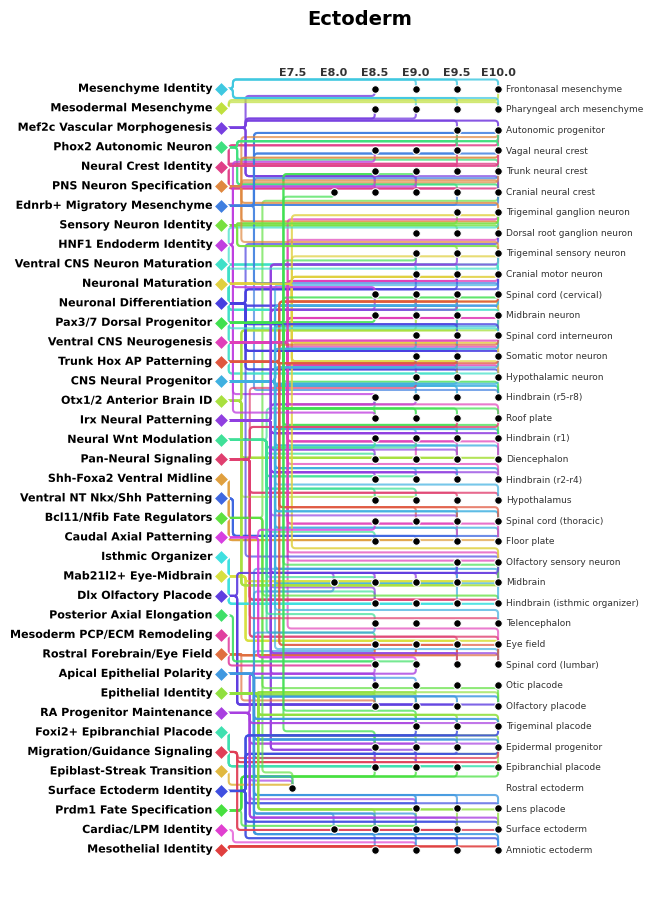

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from collections import defaultdict
import colorsys


GERM_LAYER = "Ectoderm"

FILTER_QUANTILE    = 0.2
SCORE_THRESHOLD    = 0.7

FIG_SIZE           = (6,11)
GRID_SPACING_X     = 2.0
GRID_SPACING_Y     = 1.0

PROG_COL_OFFSET    = 3.5
PROG_NODE_CLEARANCE = 0.4
TRUNK_MARGIN_INNER = 0.03
PARALLEL_OFFSET    = 0.2
CORRIDOR_MARGIN    = 0.05
CORNER_RADIUS      = 0.18
CORNER_ARC_PTS     = 10
TRUNK_PAD          = 0.05

EDGE_ALPHA         = (0.20, 0.88)
EDGE_LW            = (1.5, 1.5)
EDGE_WEIGHT_THRESH = 0.0

GRID_NODE_SIZE     = 30
PROG_NODE_SIZE     = 60
PROG_LABEL_FONTSIZE = 8
STAGE_LABEL_FONTSIZE = 8
CT_LABEL_FONTSIZE  = 6.5
LABEL_OFFSET       = 0.42

CT_NODE_COLORS     = {}
CT_NODE_DEFAULT    = "black"


# colormap

def prog_colormap(n, saturation=0.72, value=0.88):
    hues = np.linspace(0, 1, n, endpoint=False)
    golden = (1 + 5**0.5) / 2
    order = sorted(range(n), key=lambda i: (i * golden) % 1)
    return [colorsys.hsv_to_rgb(hues[idx], saturation, value) for idx in order]


# load and normalise

score_df = pd.read_csv("programs/program_scores_by_stage.csv", index_col=0)
annotation_df = pd.read_csv("programs/annotated_programs.csv", index_col=0)
prog_name_map = annotation_df["name"].to_dict()

type_info = pd.read_csv("programs/cell_types.csv")
cell_type_to_germ_layer = dict(zip(type_info["cell_type"], type_info["germ_layer"]))

prog_vals = score_df[score_df.columns.difference(["cell_type", "stage"])]
mins, maxs = prog_vals.min(), prog_vals.max()
score_df[prog_vals.columns] = (prog_vals - mins) / (maxs - mins).replace(0, 1)
score_df[prog_vals.columns] = score_df[prog_vals.columns].where(
    score_df[prog_vals.columns] > SCORE_THRESHOLD, 0.0)


# global quantile filtering

meta_cols = ["cell_type", "stage"]
all_progs = [c for c in score_df.columns if c not in meta_cols]

prog_sums = score_df[all_progs].sum(axis=0)
program_cols = prog_sums[prog_sums >= prog_sums.quantile(FILTER_QUANTILE)].index.tolist()

ct_sums = score_df.groupby("cell_type")[program_cols].sum().sum(axis=1)
keep_cts = ct_sums[ct_sums >= ct_sums.quantile(FILTER_QUANTILE)].index.tolist()

score_df = score_df[score_df["cell_type"].isin(keep_cts)].copy()
print(f"global filter: {len(program_cols)}/{len(all_progs)} programs, "
      f"{len(keep_cts)} cell types (q={FILTER_QUANTILE})")


# filter to germ layer

gl_cts = [ct for ct in score_df["cell_type"].unique()
          if cell_type_to_germ_layer.get(ct) == GERM_LAYER]
score_df = score_df[score_df["cell_type"].isin(gl_cts)].copy()

# drop programs with no connections in this layer
program_cols = [pc for pc in program_cols
                if (score_df[pc] > EDGE_WEIGHT_THRESH).any()]

print(f"{GERM_LAYER}: {len(gl_cts)} cell types, {len(program_cols)} programs")


# ordering helpers

def spectral_order(W):
    if W.shape[0] <= 2:
        return np.arange(W.shape[0])
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    S = (W / norms) @ (W / norms).T
    np.clip(S, 0, None, out=S)
    np.fill_diagonal(S, 0)
    L = laplacian(S, normed=False)
    _, vecs = eigh(L)
    return np.argsort(vecs[:, 1])


def barycentric_sort(W, fixed_order):
    positions = np.arange(len(fixed_order), dtype=float)
    bary = np.zeros(W.shape[0])
    for i in range(W.shape[0]):
        w = W[i, fixed_order]
        total = w.sum()
        bary[i] = np.dot(w, positions) / total if total > 0 else positions.mean()
    return np.argsort(bary)


# ordering

stage_order = sorted(score_df["stage"].unique(),
                     key=lambda s: float(s.replace("E", "")))
cell_types_unsorted = sorted(gl_cts)
n_rows = len(cell_types_unsorted)
n_cols = len(stage_order)
n_programs = len(program_cols)

ct_prog = np.zeros((n_rows, n_programs))
for idx, ct in enumerate(cell_types_unsorted):
    ct_prog[idx] = score_df[score_df["cell_type"] == ct][program_cols].max(axis=0).values

ct_perm = spectral_order(ct_prog)
for _ in range(8):
    prog_perm = barycentric_sort(ct_prog.T, ct_perm)
    ct_perm   = barycentric_sort(ct_prog, prog_perm)

cell_types = [cell_types_unsorted[i] for i in ct_perm]
program_cols_ordered = [program_cols[i] for i in prog_perm]
ct_to_row = {ct: i for i, ct in enumerate(cell_types)}
stage_to_col = {st: j for j, st in enumerate(stage_order)}


# layout

grid_xs = np.arange(n_cols) * GRID_SPACING_X
grid_xs -= grid_xs.mean()
grid_ys = np.arange(n_rows) * GRID_SPACING_Y
grid_ys -= grid_ys.mean()

grid_pos = {}
for _, row in score_df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    grid_pos[(ct, st)] = (grid_xs[stage_to_col[st]], grid_ys[ct_to_row[ct]])

prog_x_base = grid_xs.min() - PROG_COL_OFFSET
prog_ys_arr = np.linspace(grid_ys.min(), grid_ys.max(), n_programs)
prog_pos = {pc: (prog_x_base, prog_ys_arr[i])
            for i, pc in enumerate(program_cols_ordered)}


# channel reuse for trunk lines

trunk_zone_L = prog_x_base + PROG_NODE_CLEARANCE
trunk_zone_R = grid_xs.min() - TRUNK_MARGIN_INNER

prog_y_intervals = {}
prog_com_y = {}
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    target_ys, ws = [py], []
    for _, row in score_df.iterrows():
        if row[pc] > EDGE_WEIGHT_THRESH:
            y = grid_ys[ct_to_row[row["cell_type"]]]
            target_ys.append(y)
            ws.append(row[pc])
    prog_y_intervals[pc] = (min(target_ys) - TRUNK_PAD, max(target_ys) + TRUNK_PAD)
    prog_com_y[pc] = (np.average([t for t in target_ys[1:]], weights=ws)
                      if ws else py)

progs_by_com = sorted(program_cols_ordered, key=lambda p: prog_com_y[p])

channels = []
prog_channel = {}
for pc in progs_by_com:
    iv = prog_y_intervals[pc]
    placed = False
    for ci, ext in enumerate(channels):
        if iv[0] >= ext[1] or iv[1] <= ext[0]:
            channels[ci] = (min(ext[0], iv[0]), max(ext[1], iv[1]))
            prog_channel[pc] = ci
            placed = True
            break
    if not placed:
        prog_channel[pc] = len(channels)
        channels.append(iv)

n_channels = len(channels)
print(f"trunk channels: {n_channels}")

channel_xs = (np.array([(trunk_zone_L + trunk_zone_R) / 2.0]) if n_channels == 1
              else np.linspace(trunk_zone_L, trunk_zone_R, n_channels))
prog_trunk_x = {pc: channel_xs[prog_channel[pc]] for pc in program_cols_ordered}


# corridor routing

row_midpoint_above = {}
row_midpoint_below = {}
for r in range(n_rows):
    row_midpoint_above[r] = ((grid_ys[r] + grid_ys[r + 1]) / 2.0
                              if r + 1 < n_rows
                              else grid_ys[r] + GRID_SPACING_Y / 2.0)
    row_midpoint_below[r] = ((grid_ys[r] + grid_ys[r - 1]) / 2.0
                              if r - 1 >= 0
                              else grid_ys[r] - GRID_SPACING_Y / 2.0)

edge_direction = {}
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    for r in range(n_rows):
        edge_direction[(r, pc)] = 1 if py >= grid_ys[r] else -1

corridor_progs = defaultdict(set)
for _, row in score_df.iterrows():
    r = ct_to_row[row["cell_type"]]
    for pc in program_cols_ordered:
        if row[pc] > EDGE_WEIGHT_THRESH:
            corridor_progs[(r, edge_direction[(r, pc)])].add(pc)

corridor_prog_voff = {}
for (r, d), progs in corridor_progs.items():
    ordered = sorted(progs, key=lambda p: prog_trunk_x[p])
    for i, pc in enumerate(ordered):
        corridor_prog_voff[(r, d, pc)] = (i - (len(ordered) - 1) / 2.0) * PARALLEL_OFFSET


# edge geometry

def quad_arc(a, corner, b, n_pts):
    t = np.linspace(0, 1, n_pts)[:, None]
    a, corner, b = map(np.asarray, (a, corner, b))
    return (1 - t)**2 * a + 2 * (1 - t) * t * corner + t**2 * b


def rounded_ortho(waypoints, radius=CORNER_RADIUS, n_arc=CORNER_ARC_PTS):
    pts = [np.asarray(p, dtype=float) for p in waypoints]
    if len(pts) < 3:
        return np.array(pts)
    out = [pts[0].copy()]
    for i in range(1, len(pts) - 1):
        prev, cur, nxt = pts[i - 1], pts[i], pts[i + 1]
        d1, d2 = cur - prev, nxt - cur
        L1, L2 = np.linalg.norm(d1), np.linalg.norm(d2)
        r = min(radius, L1 / 2.0, L2 / 2.0)
        if r < 1e-8 or L1 < 1e-8 or L2 < 1e-8:
            out.append(cur.copy())
            continue
        out.extend(quad_arc(cur - (d1 / L1) * r, cur,
                            cur + (d2 / L2) * r, n_arc).tolist())
    out.append(pts[-1].copy())
    return np.array(out)


# colors

prog_colors = {pc: c for pc, c in zip(program_cols_ordered,
                                       prog_colormap(n_programs))}
ct_colors = {ct: CT_NODE_COLORS.get(ct, CT_NODE_DEFAULT) for ct in cell_types}


# draw

if FIG_SIZE is None:
    fig_w = max(6, 2 + n_cols * 1.2 + 3)
    fig_h = max(4, n_rows * 0.55 + 2)
else:
    fig_w, fig_h = FIG_SIZE

fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(GERM_LAYER, fontsize=14, fontweight="bold", pad=12)

w_max = score_df[program_cols].values.max() or 1.0

# edges
for _, row in score_df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    r = ct_to_row[ct]
    gx, gy = grid_pos[(ct, st)]
    for pc in program_cols_ordered:
        w = row[pc]
        if w <= EDGE_WEIGHT_THRESH:
            continue
        px, py = prog_pos[pc]
        tx = prog_trunk_x[pc]
        d = edge_direction[(r, pc)]
        v_off = corridor_prog_voff.get((r, d, pc), 0.0)

        base_y = row_midpoint_above[r] if d == 1 else row_midpoint_below[r]
        corridor_y = base_y - d * CORRIDOR_MARGIN + v_off

        curve = rounded_ortho([(px, py), (tx, py), (tx, corridor_y),
                                (gx, corridor_y), (gx, gy)])
        t = w / w_max
        ax.plot(curve[:, 0], curve[:, 1], color=prog_colors[pc],
                alpha=EDGE_ALPHA[0] + (EDGE_ALPHA[1] - EDGE_ALPHA[0]) * t,
                lw=EDGE_LW[0] + (EDGE_LW[1] - EDGE_LW[0]) * t,
                solid_capstyle="round", solid_joinstyle="round", zorder=1)

# grid nodes
for (ct, st), (x, y) in grid_pos.items():
    ax.scatter(x, y, s=GRID_NODE_SIZE, c=ct_colors[ct],
               edgecolors="white", linewidths=0.8, zorder=5)

# program nodes and labels
for pc, (x, y) in prog_pos.items():
    ax.scatter(x, y, s=PROG_NODE_SIZE, c=[prog_colors[pc]],
               edgecolors="white", linewidths=1.2, zorder=5, marker="D")
    label = prog_name_map.get(pc, pc)
    ax.text(x - LABEL_OFFSET, y, label, fontsize=PROG_LABEL_FONTSIZE,
            fontweight="bold", ha="right", va="center",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")])

# stage labels
for st, j in stage_to_col.items():
    ax.text(grid_xs[j], grid_ys.max() + 0.55, st, ha="center", va="bottom",
            fontsize=STAGE_LABEL_FONTSIZE, fontweight="bold", color="#333")

# cell type labels with anti-overlap
ct_label_positions = [(ct, grid_ys[ct_to_row[ct]]) for ct in cell_types]
min_gap = 0.28
adjusted = []
for ct, y in ct_label_positions:
    if adjusted and y - adjusted[-1][1] < min_gap:
        y = adjusted[-1][1] + min_gap
    adjusted.append((ct, y))
for ct, y in adjusted:
    ax.text(grid_xs.max() + 0.4, y, ct, ha="left", va="center",
            fontsize=CT_LABEL_FONTSIZE, color="#333")

# plt.tight_layout()
plt.show()

global filter: 61/76 programs, 77 cell types (q=0.2)
Mesoderm: 28 cell types, 38 programs
trunk channels: 15


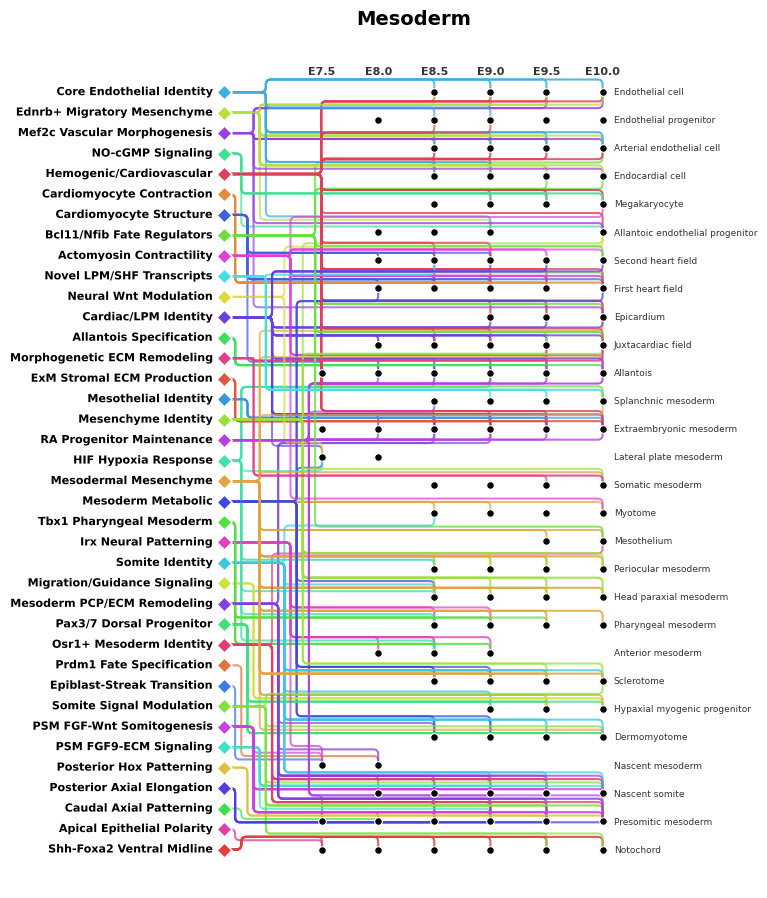

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from collections import defaultdict
import colorsys


GERM_LAYER = "Mesoderm"

FILTER_QUANTILE    = 0.2
SCORE_THRESHOLD    = 0.7

FIG_SIZE           = (6,11)
GRID_SPACING_X     = 2.0
GRID_SPACING_Y     = 1.0

PROG_COL_OFFSET    = 3.5
PROG_NODE_CLEARANCE = 0.4
TRUNK_MARGIN_INNER = 0.03
PARALLEL_OFFSET    = 0.12
CORRIDOR_MARGIN    = 0.05
CORNER_RADIUS      = 0.18
CORNER_ARC_PTS     = 10
TRUNK_PAD          = 0.05

EDGE_ALPHA         = (0.20, 0.88)
EDGE_LW            = (1.5, 1.5)
EDGE_WEIGHT_THRESH = 0.0

GRID_NODE_SIZE     = 30
PROG_NODE_SIZE     = 60
PROG_LABEL_FONTSIZE = 8
STAGE_LABEL_FONTSIZE = 8
CT_LABEL_FONTSIZE  = 6.5
LABEL_OFFSET       = 0.42

CT_NODE_COLORS     = {}
CT_NODE_DEFAULT    = "black"


# colormap

def prog_colormap(n, saturation=0.72, value=0.88):
    hues = np.linspace(0, 1, n, endpoint=False)
    golden = (1 + 5**0.5) / 2
    order = sorted(range(n), key=lambda i: (i * golden) % 1)
    return [colorsys.hsv_to_rgb(hues[idx], saturation, value) for idx in order]


# load and normalise

score_df = pd.read_csv("programs/program_scores_by_stage.csv", index_col=0)
annotation_df = pd.read_csv("programs/annotated_programs.csv", index_col=0)
prog_name_map = annotation_df["name"].to_dict()

type_info = pd.read_csv("programs/cell_types.csv")
cell_type_to_germ_layer = dict(zip(type_info["cell_type"], type_info["germ_layer"]))

prog_vals = score_df[score_df.columns.difference(["cell_type", "stage"])]
mins, maxs = prog_vals.min(), prog_vals.max()
score_df[prog_vals.columns] = (prog_vals - mins) / (maxs - mins).replace(0, 1)
score_df[prog_vals.columns] = score_df[prog_vals.columns].where(
    score_df[prog_vals.columns] > SCORE_THRESHOLD, 0.0)


# global quantile filtering

meta_cols = ["cell_type", "stage"]
all_progs = [c for c in score_df.columns if c not in meta_cols]

prog_sums = score_df[all_progs].sum(axis=0)
program_cols = prog_sums[prog_sums >= prog_sums.quantile(FILTER_QUANTILE)].index.tolist()

ct_sums = score_df.groupby("cell_type")[program_cols].sum().sum(axis=1)
keep_cts = ct_sums[ct_sums >= ct_sums.quantile(FILTER_QUANTILE)].index.tolist()

score_df = score_df[score_df["cell_type"].isin(keep_cts)].copy()
print(f"global filter: {len(program_cols)}/{len(all_progs)} programs, "
      f"{len(keep_cts)} cell types (q={FILTER_QUANTILE})")


# filter to germ layer

gl_cts = [ct for ct in score_df["cell_type"].unique()
          if cell_type_to_germ_layer.get(ct) == GERM_LAYER]
score_df = score_df[score_df["cell_type"].isin(gl_cts)].copy()

# drop programs with no connections in this layer
program_cols = [pc for pc in program_cols
                if (score_df[pc] > EDGE_WEIGHT_THRESH).any()]

print(f"{GERM_LAYER}: {len(gl_cts)} cell types, {len(program_cols)} programs")


# ordering helpers

def spectral_order(W):
    if W.shape[0] <= 2:
        return np.arange(W.shape[0])
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    S = (W / norms) @ (W / norms).T
    np.clip(S, 0, None, out=S)
    np.fill_diagonal(S, 0)
    L = laplacian(S, normed=False)
    _, vecs = eigh(L)
    return np.argsort(vecs[:, 1])


def barycentric_sort(W, fixed_order):
    positions = np.arange(len(fixed_order), dtype=float)
    bary = np.zeros(W.shape[0])
    for i in range(W.shape[0]):
        w = W[i, fixed_order]
        total = w.sum()
        bary[i] = np.dot(w, positions) / total if total > 0 else positions.mean()
    return np.argsort(bary)


# ordering

stage_order = sorted(score_df["stage"].unique(),
                     key=lambda s: float(s.replace("E", "")))
cell_types_unsorted = sorted(gl_cts)
n_rows = len(cell_types_unsorted)
n_cols = len(stage_order)
n_programs = len(program_cols)

ct_prog = np.zeros((n_rows, n_programs))
for idx, ct in enumerate(cell_types_unsorted):
    ct_prog[idx] = score_df[score_df["cell_type"] == ct][program_cols].max(axis=0).values

ct_perm = spectral_order(ct_prog)
for _ in range(8):
    prog_perm = barycentric_sort(ct_prog.T, ct_perm)
    ct_perm   = barycentric_sort(ct_prog, prog_perm)

cell_types = [cell_types_unsorted[i] for i in ct_perm]
program_cols_ordered = [program_cols[i] for i in prog_perm]
ct_to_row = {ct: i for i, ct in enumerate(cell_types)}
stage_to_col = {st: j for j, st in enumerate(stage_order)}


# layout

grid_xs = np.arange(n_cols) * GRID_SPACING_X
grid_xs -= grid_xs.mean()
grid_ys = np.arange(n_rows) * GRID_SPACING_Y
grid_ys -= grid_ys.mean()

grid_pos = {}
for _, row in score_df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    grid_pos[(ct, st)] = (grid_xs[stage_to_col[st]], grid_ys[ct_to_row[ct]])

prog_x_base = grid_xs.min() - PROG_COL_OFFSET
prog_ys_arr = np.linspace(grid_ys.min(), grid_ys.max(), n_programs)
prog_pos = {pc: (prog_x_base, prog_ys_arr[i])
            for i, pc in enumerate(program_cols_ordered)}


# channel reuse for trunk lines

trunk_zone_L = prog_x_base + PROG_NODE_CLEARANCE
trunk_zone_R = grid_xs.min() - TRUNK_MARGIN_INNER

prog_y_intervals = {}
prog_com_y = {}
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    target_ys, ws = [py], []
    for _, row in score_df.iterrows():
        if row[pc] > EDGE_WEIGHT_THRESH:
            y = grid_ys[ct_to_row[row["cell_type"]]]
            target_ys.append(y)
            ws.append(row[pc])
    prog_y_intervals[pc] = (min(target_ys) - TRUNK_PAD, max(target_ys) + TRUNK_PAD)
    prog_com_y[pc] = (np.average([t for t in target_ys[1:]], weights=ws)
                      if ws else py)

progs_by_com = sorted(program_cols_ordered, key=lambda p: prog_com_y[p])

channels = []
prog_channel = {}
for pc in progs_by_com:
    iv = prog_y_intervals[pc]
    placed = False
    for ci, ext in enumerate(channels):
        if iv[0] >= ext[1] or iv[1] <= ext[0]:
            channels[ci] = (min(ext[0], iv[0]), max(ext[1], iv[1]))
            prog_channel[pc] = ci
            placed = True
            break
    if not placed:
        prog_channel[pc] = len(channels)
        channels.append(iv)

n_channels = len(channels)
print(f"trunk channels: {n_channels}")

channel_xs = (np.array([(trunk_zone_L + trunk_zone_R) / 2.0]) if n_channels == 1
              else np.linspace(trunk_zone_L, trunk_zone_R, n_channels))
prog_trunk_x = {pc: channel_xs[prog_channel[pc]] for pc in program_cols_ordered}


# corridor routing

row_midpoint_above = {}
row_midpoint_below = {}
for r in range(n_rows):
    row_midpoint_above[r] = ((grid_ys[r] + grid_ys[r + 1]) / 2.0
                              if r + 1 < n_rows
                              else grid_ys[r] + GRID_SPACING_Y / 2.0)
    row_midpoint_below[r] = ((grid_ys[r] + grid_ys[r - 1]) / 2.0
                              if r - 1 >= 0
                              else grid_ys[r] - GRID_SPACING_Y / 2.0)

edge_direction = {}
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    for r in range(n_rows):
        edge_direction[(r, pc)] = 1 if py >= grid_ys[r] else -1

corridor_progs = defaultdict(set)
for _, row in score_df.iterrows():
    r = ct_to_row[row["cell_type"]]
    for pc in program_cols_ordered:
        if row[pc] > EDGE_WEIGHT_THRESH:
            corridor_progs[(r, edge_direction[(r, pc)])].add(pc)

corridor_prog_voff = {}
for (r, d), progs in corridor_progs.items():
    ordered = sorted(progs, key=lambda p: prog_trunk_x[p])
    for i, pc in enumerate(ordered):
        corridor_prog_voff[(r, d, pc)] = (i - (len(ordered) - 1) / 2.0) * PARALLEL_OFFSET


# edge geometry

def quad_arc(a, corner, b, n_pts):
    t = np.linspace(0, 1, n_pts)[:, None]
    a, corner, b = map(np.asarray, (a, corner, b))
    return (1 - t)**2 * a + 2 * (1 - t) * t * corner + t**2 * b


def rounded_ortho(waypoints, radius=CORNER_RADIUS, n_arc=CORNER_ARC_PTS):
    pts = [np.asarray(p, dtype=float) for p in waypoints]
    if len(pts) < 3:
        return np.array(pts)
    out = [pts[0].copy()]
    for i in range(1, len(pts) - 1):
        prev, cur, nxt = pts[i - 1], pts[i], pts[i + 1]
        d1, d2 = cur - prev, nxt - cur
        L1, L2 = np.linalg.norm(d1), np.linalg.norm(d2)
        r = min(radius, L1 / 2.0, L2 / 2.0)
        if r < 1e-8 or L1 < 1e-8 or L2 < 1e-8:
            out.append(cur.copy())
            continue
        out.extend(quad_arc(cur - (d1 / L1) * r, cur,
                            cur + (d2 / L2) * r, n_arc).tolist())
    out.append(pts[-1].copy())
    return np.array(out)


# colors

prog_colors = {pc: c for pc, c in zip(program_cols_ordered,
                                       prog_colormap(n_programs))}
ct_colors = {ct: CT_NODE_COLORS.get(ct, CT_NODE_DEFAULT) for ct in cell_types}


# draw

if FIG_SIZE is None:
    fig_w = max(6, 2 + n_cols * 1.2 + 3)
    fig_h = max(4, n_rows * 0.55 + 2)
else:
    fig_w, fig_h = FIG_SIZE

fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(GERM_LAYER, fontsize=14, fontweight="bold", pad=12)

w_max = score_df[program_cols].values.max() or 1.0

# edges
for _, row in score_df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    r = ct_to_row[ct]
    gx, gy = grid_pos[(ct, st)]
    for pc in program_cols_ordered:
        w = row[pc]
        if w <= EDGE_WEIGHT_THRESH:
            continue
        px, py = prog_pos[pc]
        tx = prog_trunk_x[pc]
        d = edge_direction[(r, pc)]
        v_off = corridor_prog_voff.get((r, d, pc), 0.0)

        base_y = row_midpoint_above[r] if d == 1 else row_midpoint_below[r]
        corridor_y = base_y - d * CORRIDOR_MARGIN + v_off

        curve = rounded_ortho([(px, py), (tx, py), (tx, corridor_y),
                                (gx, corridor_y), (gx, gy)])
        t = w / w_max
        ax.plot(curve[:, 0], curve[:, 1], color=prog_colors[pc],
                alpha=EDGE_ALPHA[0] + (EDGE_ALPHA[1] - EDGE_ALPHA[0]) * t,
                lw=EDGE_LW[0] + (EDGE_LW[1] - EDGE_LW[0]) * t,
                solid_capstyle="round", solid_joinstyle="round", zorder=1)

# grid nodes
for (ct, st), (x, y) in grid_pos.items():
    ax.scatter(x, y, s=GRID_NODE_SIZE, c=ct_colors[ct],
               edgecolors="white", linewidths=0.8, zorder=5)

# program nodes and labels
for pc, (x, y) in prog_pos.items():
    ax.scatter(x, y, s=PROG_NODE_SIZE, c=[prog_colors[pc]],
               edgecolors="white", linewidths=1.2, zorder=5, marker="D")
    label = prog_name_map.get(pc, pc)
    ax.text(x - LABEL_OFFSET, y, label, fontsize=PROG_LABEL_FONTSIZE,
            fontweight="bold", ha="right", va="center",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")])

# stage labels
for st, j in stage_to_col.items():
    ax.text(grid_xs[j], grid_ys.max() + 0.55, st, ha="center", va="bottom",
            fontsize=STAGE_LABEL_FONTSIZE, fontweight="bold", color="#333")

# cell type labels with anti-overlap
ct_label_positions = [(ct, grid_ys[ct_to_row[ct]]) for ct in cell_types]
min_gap = 0.28
adjusted = []
for ct, y in ct_label_positions:
    if adjusted and y - adjusted[-1][1] < min_gap:
        y = adjusted[-1][1] + min_gap
    adjusted.append((ct, y))
for ct, y in adjusted:
    ax.text(grid_xs.max() + 0.4, y, ct, ha="left", va="center",
            fontsize=CT_LABEL_FONTSIZE, color="#333")

# plt.tight_layout()
plt.show()

global filter: 61/76 programs, 77 cell types (q=0.2)
Endoderm: 8 cell types, 10 programs
trunk channels: 5


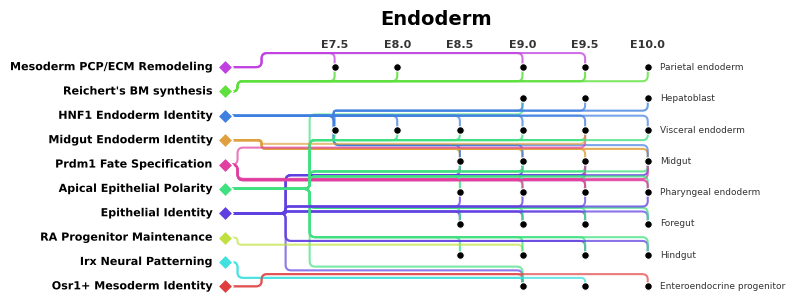

In [27]:
GERM_LAYER = "Endoderm"

FILTER_QUANTILE    = 0.2
SCORE_THRESHOLD    = 0.7

FIG_SIZE           = (6,6)
GRID_SPACING_X     = 2.0
GRID_SPACING_Y     = 1.0

PROG_COL_OFFSET    = 3.5
PROG_NODE_CLEARANCE = 0.4
TRUNK_MARGIN_INNER = 0.03
PARALLEL_OFFSET    = 0.12
CORRIDOR_MARGIN    = 0.05
CORNER_RADIUS      = 0.18
CORNER_ARC_PTS     = 10
TRUNK_PAD          = 0.05

EDGE_ALPHA         = (0.20, 0.88)
EDGE_LW            = (1.5, 1.5)
EDGE_WEIGHT_THRESH = 0.0

GRID_NODE_SIZE     = 30
PROG_NODE_SIZE     = 60
PROG_LABEL_FONTSIZE = 8
STAGE_LABEL_FONTSIZE = 8
CT_LABEL_FONTSIZE  = 6.5
LABEL_OFFSET       = 0.42

CT_NODE_COLORS     = {}
CT_NODE_DEFAULT    = "black"


# colormap

def prog_colormap(n, saturation=0.72, value=0.88):
    hues = np.linspace(0, 1, n, endpoint=False)
    golden = (1 + 5**0.5) / 2
    order = sorted(range(n), key=lambda i: (i * golden) % 1)
    return [colorsys.hsv_to_rgb(hues[idx], saturation, value) for idx in order]


# load and normalise

score_df = pd.read_csv("programs/program_scores_by_stage.csv", index_col=0)
annotation_df = pd.read_csv("programs/annotated_programs.csv", index_col=0)
prog_name_map = annotation_df["name"].to_dict()

type_info = pd.read_csv("programs/cell_types.csv")
cell_type_to_germ_layer = dict(zip(type_info["cell_type"], type_info["germ_layer"]))

prog_vals = score_df[score_df.columns.difference(["cell_type", "stage"])]
mins, maxs = prog_vals.min(), prog_vals.max()
score_df[prog_vals.columns] = (prog_vals - mins) / (maxs - mins).replace(0, 1)
score_df[prog_vals.columns] = score_df[prog_vals.columns].where(
    score_df[prog_vals.columns] > SCORE_THRESHOLD, 0.0)


# global quantile filtering

meta_cols = ["cell_type", "stage"]
all_progs = [c for c in score_df.columns if c not in meta_cols]

prog_sums = score_df[all_progs].sum(axis=0)
program_cols = prog_sums[prog_sums >= prog_sums.quantile(FILTER_QUANTILE)].index.tolist()

ct_sums = score_df.groupby("cell_type")[program_cols].sum().sum(axis=1)
keep_cts = ct_sums[ct_sums >= ct_sums.quantile(FILTER_QUANTILE)].index.tolist()

score_df = score_df[score_df["cell_type"].isin(keep_cts)].copy()
print(f"global filter: {len(program_cols)}/{len(all_progs)} programs, "
      f"{len(keep_cts)} cell types (q={FILTER_QUANTILE})")


# filter to germ layer

gl_cts = [ct for ct in score_df["cell_type"].unique()
          if cell_type_to_germ_layer.get(ct) == GERM_LAYER]
score_df = score_df[score_df["cell_type"].isin(gl_cts)].copy()

# drop programs with no connections in this layer
program_cols = [pc for pc in program_cols
                if (score_df[pc] > EDGE_WEIGHT_THRESH).any()]

print(f"{GERM_LAYER}: {len(gl_cts)} cell types, {len(program_cols)} programs")


# ordering helpers

def spectral_order(W):
    if W.shape[0] <= 2:
        return np.arange(W.shape[0])
    norms = np.linalg.norm(W, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1, norms)
    S = (W / norms) @ (W / norms).T
    np.clip(S, 0, None, out=S)
    np.fill_diagonal(S, 0)
    L = laplacian(S, normed=False)
    _, vecs = eigh(L)
    return np.argsort(vecs[:, 1])


def barycentric_sort(W, fixed_order):
    positions = np.arange(len(fixed_order), dtype=float)
    bary = np.zeros(W.shape[0])
    for i in range(W.shape[0]):
        w = W[i, fixed_order]
        total = w.sum()
        bary[i] = np.dot(w, positions) / total if total > 0 else positions.mean()
    return np.argsort(bary)


# ordering

stage_order = sorted(score_df["stage"].unique(),
                     key=lambda s: float(s.replace("E", "")))
cell_types_unsorted = sorted(gl_cts)
n_rows = len(cell_types_unsorted)
n_cols = len(stage_order)
n_programs = len(program_cols)

ct_prog = np.zeros((n_rows, n_programs))
for idx, ct in enumerate(cell_types_unsorted):
    ct_prog[idx] = score_df[score_df["cell_type"] == ct][program_cols].max(axis=0).values

ct_perm = spectral_order(ct_prog)
for _ in range(8):
    prog_perm = barycentric_sort(ct_prog.T, ct_perm)
    ct_perm   = barycentric_sort(ct_prog, prog_perm)

cell_types = [cell_types_unsorted[i] for i in ct_perm]
program_cols_ordered = [program_cols[i] for i in prog_perm]
ct_to_row = {ct: i for i, ct in enumerate(cell_types)}
stage_to_col = {st: j for j, st in enumerate(stage_order)}


# layout

grid_xs = np.arange(n_cols) * GRID_SPACING_X
grid_xs -= grid_xs.mean()
grid_ys = np.arange(n_rows) * GRID_SPACING_Y
grid_ys -= grid_ys.mean()

grid_pos = {}
for _, row in score_df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    grid_pos[(ct, st)] = (grid_xs[stage_to_col[st]], grid_ys[ct_to_row[ct]])

prog_x_base = grid_xs.min() - PROG_COL_OFFSET
prog_ys_arr = np.linspace(grid_ys.min(), grid_ys.max(), n_programs)
prog_pos = {pc: (prog_x_base, prog_ys_arr[i])
            for i, pc in enumerate(program_cols_ordered)}


# channel reuse for trunk lines

trunk_zone_L = prog_x_base + PROG_NODE_CLEARANCE
trunk_zone_R = grid_xs.min() - TRUNK_MARGIN_INNER

prog_y_intervals = {}
prog_com_y = {}
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    target_ys, ws = [py], []
    for _, row in score_df.iterrows():
        if row[pc] > EDGE_WEIGHT_THRESH:
            y = grid_ys[ct_to_row[row["cell_type"]]]
            target_ys.append(y)
            ws.append(row[pc])
    prog_y_intervals[pc] = (min(target_ys) - TRUNK_PAD, max(target_ys) + TRUNK_PAD)
    prog_com_y[pc] = (np.average([t for t in target_ys[1:]], weights=ws)
                      if ws else py)

progs_by_com = sorted(program_cols_ordered, key=lambda p: prog_com_y[p])

channels = []
prog_channel = {}
for pc in progs_by_com:
    iv = prog_y_intervals[pc]
    placed = False
    for ci, ext in enumerate(channels):
        if iv[0] >= ext[1] or iv[1] <= ext[0]:
            channels[ci] = (min(ext[0], iv[0]), max(ext[1], iv[1]))
            prog_channel[pc] = ci
            placed = True
            break
    if not placed:
        prog_channel[pc] = len(channels)
        channels.append(iv)

n_channels = len(channels)
print(f"trunk channels: {n_channels}")

channel_xs = (np.array([(trunk_zone_L + trunk_zone_R) / 2.0]) if n_channels == 1
              else np.linspace(trunk_zone_L, trunk_zone_R, n_channels))
prog_trunk_x = {pc: channel_xs[prog_channel[pc]] for pc in program_cols_ordered}


# corridor routing

row_midpoint_above = {}
row_midpoint_below = {}
for r in range(n_rows):
    row_midpoint_above[r] = ((grid_ys[r] + grid_ys[r + 1]) / 2.0
                              if r + 1 < n_rows
                              else grid_ys[r] + GRID_SPACING_Y / 2.0)
    row_midpoint_below[r] = ((grid_ys[r] + grid_ys[r - 1]) / 2.0
                              if r - 1 >= 0
                              else grid_ys[r] - GRID_SPACING_Y / 2.0)

edge_direction = {}
for pc in program_cols_ordered:
    py = prog_pos[pc][1]
    for r in range(n_rows):
        edge_direction[(r, pc)] = 1 if py >= grid_ys[r] else -1

corridor_progs = defaultdict(set)
for _, row in score_df.iterrows():
    r = ct_to_row[row["cell_type"]]
    for pc in program_cols_ordered:
        if row[pc] > EDGE_WEIGHT_THRESH:
            corridor_progs[(r, edge_direction[(r, pc)])].add(pc)

corridor_prog_voff = {}
for (r, d), progs in corridor_progs.items():
    ordered = sorted(progs, key=lambda p: prog_trunk_x[p])
    for i, pc in enumerate(ordered):
        corridor_prog_voff[(r, d, pc)] = (i - (len(ordered) - 1) / 2.0) * PARALLEL_OFFSET


# edge geometry

def quad_arc(a, corner, b, n_pts):
    t = np.linspace(0, 1, n_pts)[:, None]
    a, corner, b = map(np.asarray, (a, corner, b))
    return (1 - t)**2 * a + 2 * (1 - t) * t * corner + t**2 * b


def rounded_ortho(waypoints, radius=CORNER_RADIUS, n_arc=CORNER_ARC_PTS):
    pts = [np.asarray(p, dtype=float) for p in waypoints]
    if len(pts) < 3:
        return np.array(pts)
    out = [pts[0].copy()]
    for i in range(1, len(pts) - 1):
        prev, cur, nxt = pts[i - 1], pts[i], pts[i + 1]
        d1, d2 = cur - prev, nxt - cur
        L1, L2 = np.linalg.norm(d1), np.linalg.norm(d2)
        r = min(radius, L1 / 2.0, L2 / 2.0)
        if r < 1e-8 or L1 < 1e-8 or L2 < 1e-8:
            out.append(cur.copy())
            continue
        out.extend(quad_arc(cur - (d1 / L1) * r, cur,
                            cur + (d2 / L2) * r, n_arc).tolist())
    out.append(pts[-1].copy())
    return np.array(out)


# colors

prog_colors = {pc: c for pc, c in zip(program_cols_ordered,
                                       prog_colormap(n_programs))}
ct_colors = {ct: CT_NODE_COLORS.get(ct, CT_NODE_DEFAULT) for ct in cell_types}


# draw

if FIG_SIZE is None:
    fig_w = max(6, 2 + n_cols * 1.2 + 3)
    fig_h = max(4, n_rows * 0.55 + 2)
else:
    fig_w, fig_h = FIG_SIZE

fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="white")
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(GERM_LAYER, fontsize=14, fontweight="bold", pad=12)

w_max = score_df[program_cols].values.max() or 1.0

# edges
for _, row in score_df.iterrows():
    ct, st = row["cell_type"], row["stage"]
    r = ct_to_row[ct]
    gx, gy = grid_pos[(ct, st)]
    for pc in program_cols_ordered:
        w = row[pc]
        if w <= EDGE_WEIGHT_THRESH:
            continue
        px, py = prog_pos[pc]
        tx = prog_trunk_x[pc]
        d = edge_direction[(r, pc)]
        v_off = corridor_prog_voff.get((r, d, pc), 0.0)

        base_y = row_midpoint_above[r] if d == 1 else row_midpoint_below[r]
        corridor_y = base_y - d * CORRIDOR_MARGIN + v_off

        curve = rounded_ortho([(px, py), (tx, py), (tx, corridor_y),
                                (gx, corridor_y), (gx, gy)])
        t = w / w_max
        ax.plot(curve[:, 0], curve[:, 1], color=prog_colors[pc],
                alpha=EDGE_ALPHA[0] + (EDGE_ALPHA[1] - EDGE_ALPHA[0]) * t,
                lw=EDGE_LW[0] + (EDGE_LW[1] - EDGE_LW[0]) * t,
                solid_capstyle="round", solid_joinstyle="round", zorder=1)

# grid nodes
for (ct, st), (x, y) in grid_pos.items():
    ax.scatter(x, y, s=GRID_NODE_SIZE, c=ct_colors[ct],
               edgecolors="white", linewidths=0.8, zorder=5)

# program nodes and labels
for pc, (x, y) in prog_pos.items():
    ax.scatter(x, y, s=PROG_NODE_SIZE, c=[prog_colors[pc]],
               edgecolors="white", linewidths=1.2, zorder=5, marker="D")
    label = prog_name_map.get(pc, pc)
    ax.text(x - LABEL_OFFSET, y, label, fontsize=PROG_LABEL_FONTSIZE,
            fontweight="bold", ha="right", va="center",
            path_effects=[pe.withStroke(linewidth=3, foreground="white")])

# stage labels
for st, j in stage_to_col.items():
    ax.text(grid_xs[j], grid_ys.max() + 0.55, st, ha="center", va="bottom",
            fontsize=STAGE_LABEL_FONTSIZE, fontweight="bold", color="#333")

# cell type labels with anti-overlap
ct_label_positions = [(ct, grid_ys[ct_to_row[ct]]) for ct in cell_types]
min_gap = 0.28
adjusted = []
for ct, y in ct_label_positions:
    if adjusted and y - adjusted[-1][1] < min_gap:
        y = adjusted[-1][1] + min_gap
    adjusted.append((ct, y))
for ct, y in adjusted:
    ax.text(grid_xs.max() + 0.4, y, ct, ha="left", va="center",
            fontsize=CT_LABEL_FONTSIZE, color="#333")

# plt.tight_layout()
plt.show()